In [1]:
import pandas as pd
import numpy as np
from sklearn import datasets

breast_cancer  = datasets.load_breast_cancer()
df = pd.DataFrame(data = breast_cancer .data, columns=breast_cancer .feature_names)
df['target'] = breast_cancer .target

# check data fram head
print(df.head())

# chack column name
print(df.columns)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

target
1    357
0    212
Name: count, dtype: int64
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


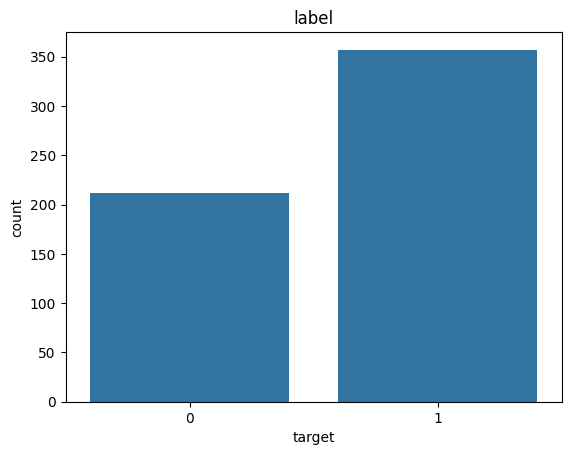

In [2]:
# check label count
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data = df, x='target')
plt.xlabel = ('Cancer or Not')
plt.ylabel = ('Count')
plt.title('label')

# check count
print(df['target'].value_counts())

# missing values check
print(df.isnull().sum())

In [3]:
# missing values delete
df = df.dropna()
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [4]:
# Feature Selection ( Random Forest by Claude )
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)     # class init
rf.fit(df.drop('target', axis=1), df['target']) # target value delete

importances = pd.Series(rf.feature_importances_, index=df.drop('target', axis=1).columns)
importances.sort_values(ascending=False).head(10)   # 높은 순으로 sort

worst perimeter         0.173987
worst radius            0.121983
worst concave points    0.118589
mean concave points     0.088527
worst area              0.074981
mean concavity          0.071862
mean perimeter          0.053993
mean area               0.045401
area error              0.039420
worst concavity         0.030394
dtype: float64

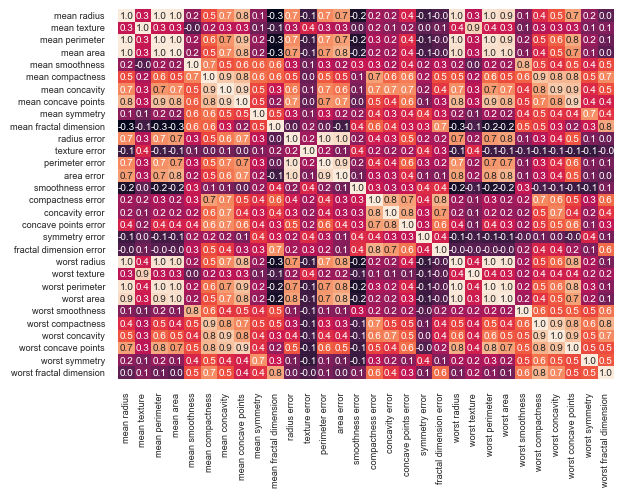

worst concave points    0.793566
worst perimeter         0.782914
mean concave points     0.776614
worst radius            0.776454
mean perimeter          0.742636
worst area              0.733825
mean radius             0.730029
mean area               0.708984
mean concavity          0.696360
worst concavity         0.659610
Name: target, dtype: float64


In [5]:
# Feature Selection ( Correlation )
import seaborn as sns
import matplotlib.pyplot as plt

cf = df.drop('target', axis=1) # target value delete
cf_matrix = cf.corr()
plt.Figure(figsize=(15,15))
sns.set(font_scale=0.6)
#sns.heatmap(cf_matrix, annot = True, cbar = False)
sns.heatmap(cf_matrix, annot=True, cbar=False, fmt='.1f')
plt.show()

# sort target by claude 
corr_target = df.corr()['target'].drop('target').abs().sort_values(ascending=False)
print(corr_target.head(10))

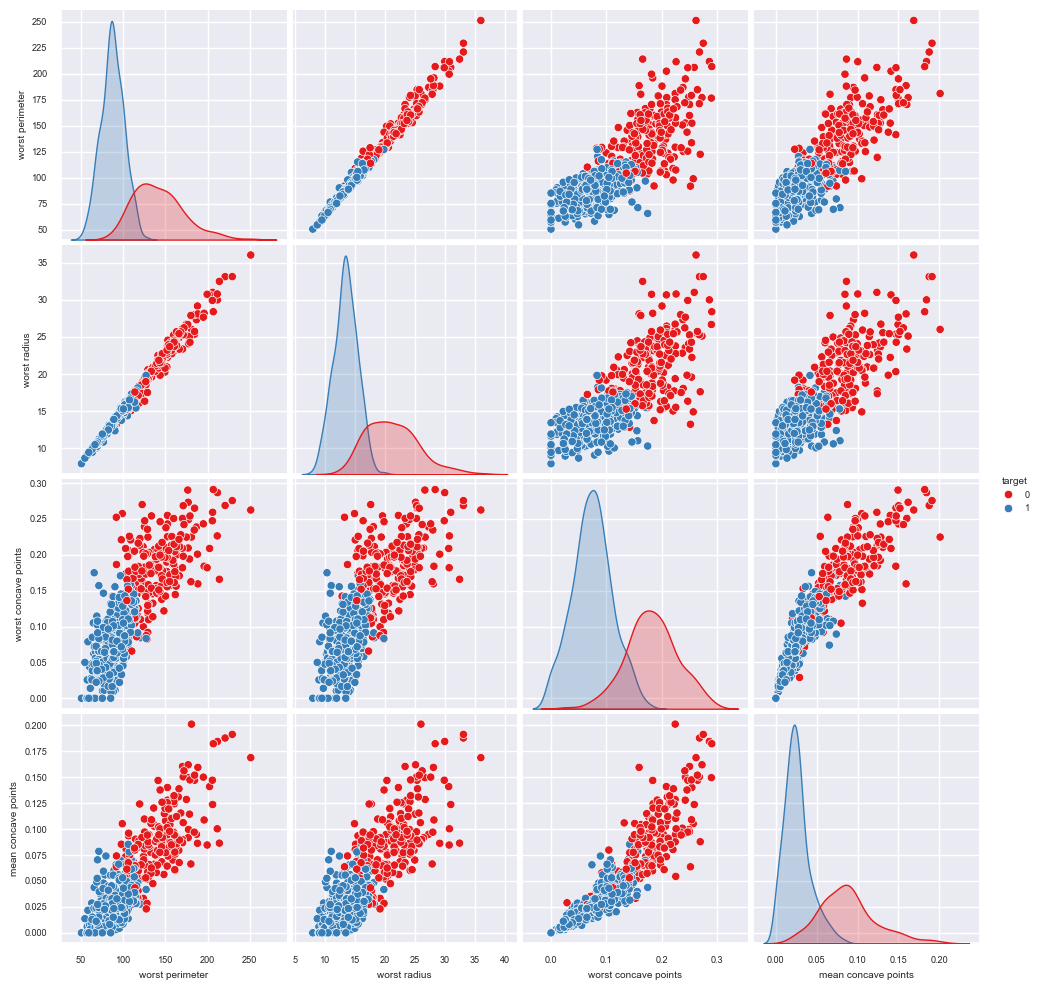

In [6]:
# check graph
sns.pairplot(df, 
             vars=['worst perimeter', 'worst radius', 'worst concave points', 'mean concave points'], 
             hue='target', 
             palette='Set1',  # 구분이 잘 가는 색상 테마
             diag_kind='kde') # 대각선에는 분포 곡선 표시
plt.show()

# check to target and label data
# 1) missing data check and delete
# 2) Feature selection use to random forest (by claude)
# 3) check graph 
# so) classification (worst perimeter, worst radius) -> good label data but x = all data
# so) regression (y = worst concave points) -> good target data

In [7]:
# Marchin Learning
# classificatoin
c_df = df.copy()
c_y = c_df['target']
c_x = c_df.drop('target', axis=1)

# regression
r_df = df.copy()
r_y = r_df['worst concave points']
r_x = r_df.drop(['target', 'worst concave points'], axis=1)

In [8]:
# classification
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report

X_train, X_test, y_train, y_test =  train_test_split(c_x, c_y, test_size=0.2, random_state=0)

c1,c2,c3 = LogisticRegression(random_state=0), DecisionTreeClassifier(random_state=0), RandomForestClassifier(random_state=0)
c1.fit(X_train, y_train); c2.fit(X_train, y_train); c3.fit(X_train,y_train)
c1_y, c2_y, c3_y = c1.predict(X_test), c2.predict(X_test), c3.predict(X_test)

print(f'Logistic Regression \n {classification_report(y_test, c1_y)}')
print(f'Decision Tree \n {classification_report(y_test, c2_y)}')
print(f'Random Forest \n {classification_report(y_test, c3_y)}')


C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95        47
           1       0.98      0.94      0.96        67

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

Decision Tree 
               precision    recall  f1-score   support

           0       0.86      0.94      0.90        47
           1       0.95      0.90      0.92        67

    accuracy                           0.91       114
   macro avg       0.91      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114

Random Forest 
               precision    recall  f1-score   support

           0       0.94      0.98      0.96        47
           1       0.98      0.96      0.97        67

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0

In [9]:
# regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_squared_error

X_train, X_test, y_train, y_test =  train_test_split(r_x, r_y, test_size=0.2, random_state=0)

r1,r2,r3 = LinearRegression(), DecisionTreeRegressor(), RandomForestRegressor()
r1.fit(X_train, y_train); r2.fit(X_train, y_train); r3.fit(X_train,y_train)
r1_y, r2_y, r3_y = r1.predict(X_test), r2.predict(X_test), r3.predict(X_test)

print(f'Linear Regression \n {mean_squared_error(y_test, r1_y)}')
print(f'Decision Tree \n {mean_squared_error(y_test, r2_y)}')
print(f'Random Forest \n {mean_squared_error(y_test, r3_y)}')

Linear Regression 
 0.00020055713998184068
Decision Tree 
 0.0005865752105263157
Random Forest 
 0.00026873972714446415


In [38]:
# Deep Learning

# classification
# One hot incoding
# Comment
# version differenct by claub
# d_c_y = pd.get_dummies(c_y).values
# d_c_x = c_x.values

d_c_y = c_y.values
d_c_x = c_x.values

# regression
d_r_y = r_y.values
d_r_x = r_x.values

print(d_c_y)
print(d_c_x)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0 1 1 1 0 1 1 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0 1 1 0 0 1 1
 1 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 0 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 1 1
 1 1 0 1 0 1 0 1 1 1 0 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 1 0 0
 0 1 0 0 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 0 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1
 1 0 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 1 1 0 1 1
 0 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 0 1
 1 1 1 1 1 1 0 1 0 1 1 0 

In [39]:
# check input shape
d_c_x.shape[1]

30

In [44]:
# classification
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

X_train,X_test, y_train,y_test = train_test_split(d_c_x,d_c_y,test_size=0.2,random_state=0) 

model = Sequential()

model.add(Dense(10, input_shape=(30,), activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
#model.add(Dense(2,activation='softmax')) # output layer
model.add(Dense(1,activation='sigmoid')) # output layer

model.compile(Adam(learning_rate=0.04), 'binary_crossentropy', metrics=['accuracy'])

model.summary()

C:\Users\Jun\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 10)             │           310 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 459 (1.79 KB)

 Trainable params: 459 (1.79 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
model_history = model.fit(
    x=X_train, y=y_train,                       # data fraim input
    epochs=30,                                  # fitting counter
    batch_size=32,                              # group count 
    validation_data= (X_test, y_test))          # fitting monitoring

y_pred = model.predict(X_test)

#y_test_class = np.argmax(y_test,axis=1)
#y_pred_class = np.argmax(y_pred,axis=1)

y_pred_class = (y_pred > 0.5).astype(int).flatten()
y_test_class = y_test

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6418 - loss: 2.4632 - val_accuracy: 0.9211 - val_loss: 0.3327
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9011 - loss: 0.3637 - val_accuracy: 0.6228 - val_loss: 0.8067
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7626 - loss: 0.5115 - val_accuracy: 0.8772 - val_loss: 0.3637
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9077 - loss: 0.2922 - val_accuracy: 0.9386 - val_loss: 0.2216
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9165 - loss: 0.2170 - val_accuracy: 0.8860 - val_loss: 0.2386
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8769 - loss: 0.3172 - val_accuracy: 0.8596 - val_loss: 0.3699
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9165 - loss: 0.2581 - val_accuracy: 0.8947 - val_loss: 0.2244
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9231 - loss: 0.2269 - val_accuracy: 0.9298 - val_loss

In [46]:
# classification
from sklearn.metrics import classification_report,confusion_matrix

print(f'Deep Learning \n {classification_report(y_test_class, y_pred_class)}')
print(f'Deep Learning \n {confusion_matrix(y_test_class, y_pred_class)}')

Deep Learning 
               precision    recall  f1-score   support

           0       1.00      0.87      0.93        47
           1       0.92      1.00      0.96        67

    accuracy                           0.95       114
   macro avg       0.96      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114

Deep Learning 
 [[41  6]
 [ 0 67]]


In [48]:
# check input shape
d_r_x.shape[1]

29

In [49]:
# regression
from sklearn.model_selection import train_test_split

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import SGD,Adam

X_train,X_test, y_train,y_test = train_test_split(d_r_x,d_r_y,test_size=0.2,random_state=0) 

model = Sequential()

model.add(Dense(10, input_shape=(29,), activation='relu'))
model.add(Dense(8,activation='relu'))
model.add(Dense(6,activation='relu'))
model.add(Dense(1)) # output layer

model.compile(optimizer = 'rmsprop', loss = 'mse', metrics = ['mse'])

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 10)             │           300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
model_history = model.fit(
    x=X_train, y=y_train,                       # data fraim input
    epochs=30,                                  # fitting counter
    batch_size=32,                              # group count 
    validation_data= (X_test, y_test))    # fitting monitoring

y_pred = model.predict(X_test)

Epoch 1/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 4.7715 - mse: 4.7715 - val_loss: 0.2240 - val_mse: 0.2240
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.5403 - mse: 5.5403 - val_loss: 0.1707 - val_mse: 0.1707
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.1184 - mse: 5.1184 - val_loss: 0.2021 - val_mse: 0.2021
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5765 - mse: 0.5765 - val_loss: 0.6208 - val_mse: 0.6208
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.7170 - mse: 4.7170 - val_loss: 2.5474 - val_mse: 2.5474
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 3.3656 - mse: 3.3656 - val_loss: 0.2288 - val_mse: 0.2288
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 4.8951 - mse: 4.8951 - val_loss: 0.2187 - val_mse: 0.2187
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5831 - mse: 3.5831 - val_loss: 4.2064 - val_mse: 4.2064
Epoch 9/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.3014 - mse: 

In [57]:
model.evaluate(X_test, y_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.2520 - mse: 2.2520 


[2.2520194053649902, 2.2520194053649902]

In [60]:
# add regression check by claude 
from sklearn.metrics import mean_squared_error, r2_score

mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print(f'Deep Learning MSE:  {mse}')
print(f'Deep Learning RMSE: {rmse}')
print(f'Deep Learning R²:   {r2}')

Deep Learning MSE:  2.252019301705144
Deep Learning RMSE: 1.5006729496146534
Deep Learning R²:   -495.58414706647676
